In [2]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd

COHERENT ONLY PLOTS:

In [4]:
coherent = pd.make_data_dictionary("../results/coherent_only_run.csv", "../results/51-full_QKE-eps.csv")
coherent.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [5]:
P0, Px, Py, Pz = pd.make_P(coherent['rho'])

In [6]:
V_coherent = pd.V_mat(coherent)

In [7]:
t = coherent['time']
Vy = V_coherent[1,:]
dy = np.diff(Vy)

In [8]:
#finding indices for zero, min, max, zero for coherent only run

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

([<matplotlib.axis.YTick at 0x1593126d0>,
 [Text(0, -200, '$-200$'),
  Text(0, -100, '$-100$'),
  Text(0, 0, '$0$'),
  Text(0, 100, '$100$'),
  Text(0, 200, '$200$')])

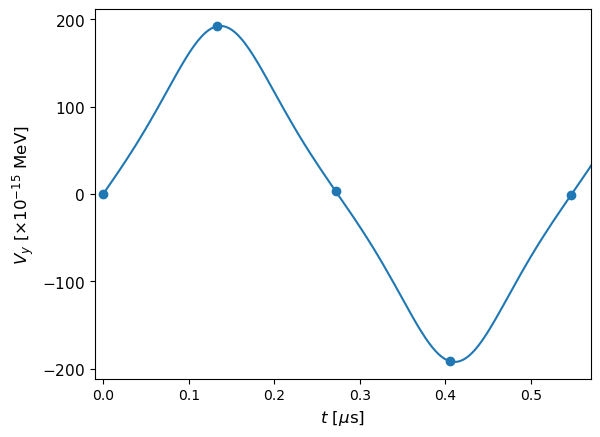

In [9]:
#plot first cycle of Vy vs t for coherent only run

plt.figure()
plt.scatter(t[t_index][0:5], Vy[Vy_index[0:5]]*1e15)
plt.plot(t[t_index[0] : t_index[5]], Vy[Vy_index[0] : Vy_index[5]]*1e15)
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
plt.xlim([-0.01,0.57])
plt.yticks([-200, -100, 0, 100, 200], [r"$-200$",r"$-100$",r"$0$",r"$100$",r"$200$"], fontsize=11)
#plt.title("Vy vs t (coherent only, first cycle)")

Text(0, 0.5, '$P_x$')

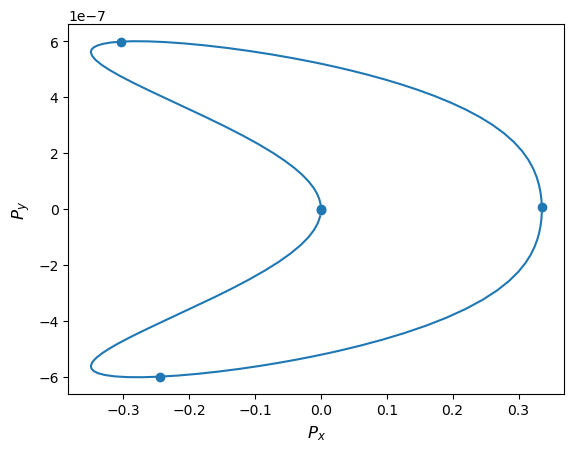

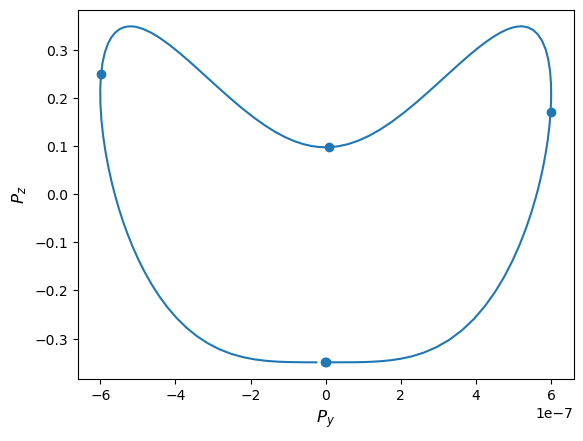

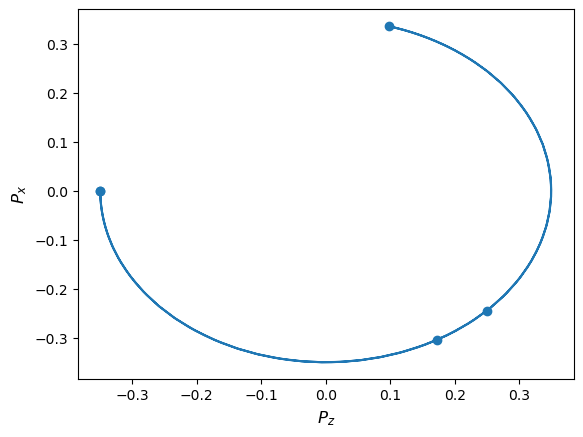

In [10]:
#plot FIRST CYCLE of bloch sphere for coherent only

plt.figure()
plt.scatter(Px[t_index,15][0:5], Py[t_index,15][0:5])
plt.plot(Px[t_index[0] : t_index[4],15], Py[t_index[0] : t_index[4],15])
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
#plt.title("Py vs Px (coherent only, first cycle)")

plt.figure()
plt.scatter(Py[t_index,15][0:5], Pz[t_index,15][0:5])
plt.plot(Py[t_index[0] : t_index[4],15], Pz[t_index[0] : t_index[4],15])
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
#plt.title("Pz vs Py (coherent only, first cycle)")

plt.figure()
plt.scatter(Pz[t_index,15][0:5], Px[t_index,15][0:5])
plt.plot(Pz[t_index[0] : t_index[4],15], Px[t_index[0] : t_index[4],15])
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
#plt.title("Px vs Pz (coherent only, first cycle)")

Text(0, 0.5, '$P_x$')

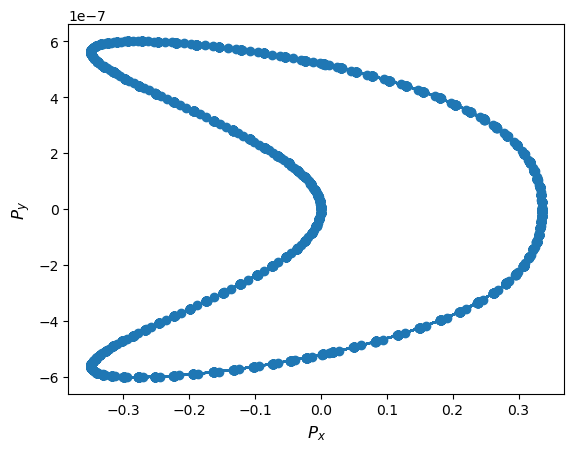

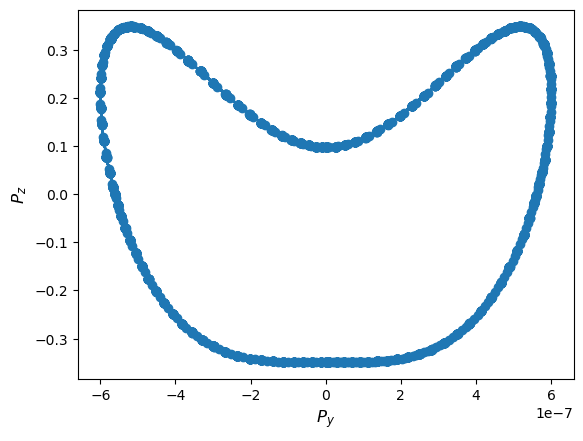

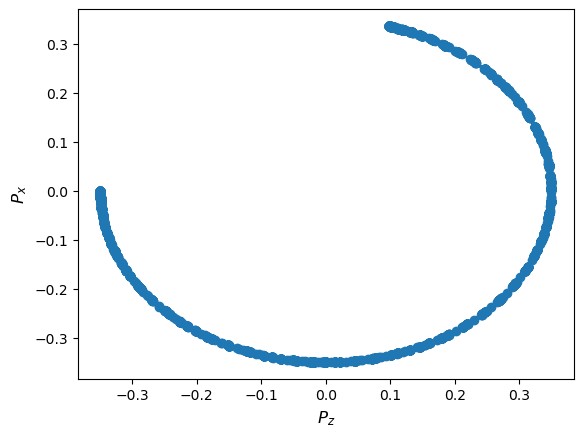

In [11]:
#Bloch Sphere evolution for coherent only ALL CYCLES

plt.figure()
plt.scatter(Px[:,15], Py[:,15])
plt.plot(Px[:,15], Py[:,15])
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
#plt.title("Py vs Px (coherent only, all cycles)")

plt.figure()
plt.scatter(Py[:,15],Pz[:,15])
plt.plot(Py[:,15],Pz[:,15])
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
#plt.title("Pz vs Py (coherent only, all cycles)")

plt.figure()
plt.scatter(Pz[:,15],Px[:,15])
plt.plot(Pz[:,15],Px[:,15])
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
#plt.title("Px vs Pz (coherent only, all cycles)")

FULL QKE PLOTS:

In [13]:
QKE = pd.make_data_dictionary("../results/62-fix_mat_small.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [14]:
P0, Px, Py, Pz = pd.make_P(QKE['rho'])

In [15]:
V_QKE = pd.V_mat(QKE)

In [16]:
t = QKE['time']
Vy = V_QKE[1,:]
dy = np.diff(Vy)

In [17]:
#Finding indices for zero, min, zero, max points (QKE)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

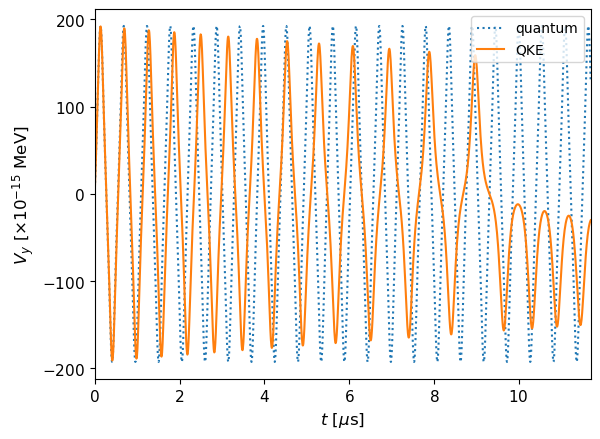

In [18]:
#QKE and coherent Vy comparison: This figure will go in preceding section, but referred to when comparing Vy for quantum vs QKE solutions

plt.figure()
plt.plot(coherent['time'], V_coherent[1,:]*1e15, ls=":", label="quantum")
plt.plot(QKE['time'], V_QKE[1,:]*1e15, label="QKE")
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
plt.xticks([0,2,4,6,8,10],[r"$0$",r"$2$",r"$4$",r"$6$",r"$8$",r"$10$"], fontsize=11)
plt.yticks([-200, -100, 0, 100, 200], [r"$-200$",r"$-100$",r"$0$",r"$100$",r"$200$"], fontsize=11)
plt.xlim(0, 11.7)
plt.legend(loc= 'upper right')
plt.show()

Text(0, 0.5, '$P_x$')

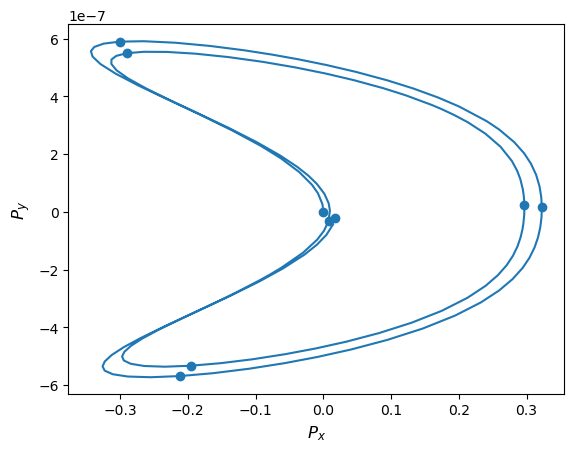

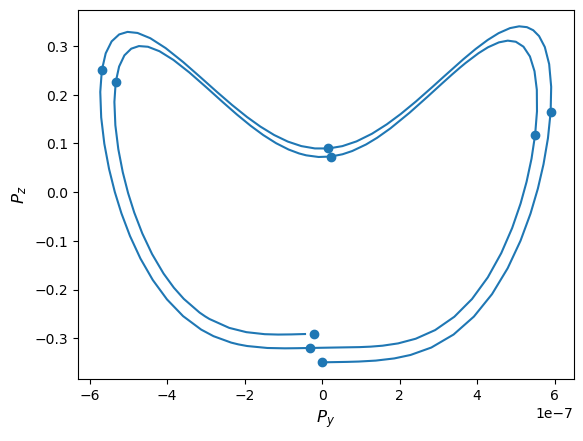

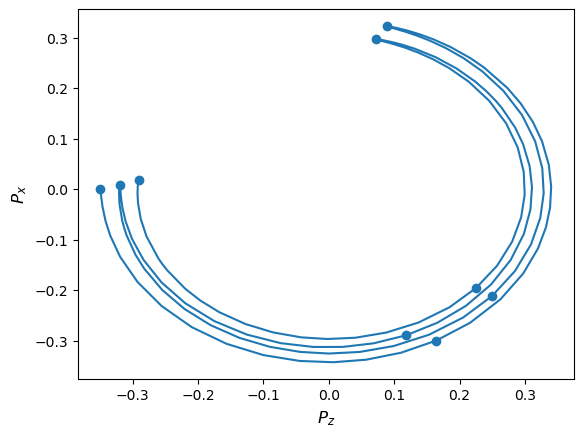

In [19]:
#Bloch Sphere plots for first 2 cycles (QKE)

plt.figure()
plt.scatter(Px[t_index,15][0:9], Py[t_index,15][0:9])
plt.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15])
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
#plt.title("Py vs Px (full QKE, first two cycles)")

plt.figure()
plt.scatter(Py[t_index,15][0:9], Pz[t_index,15][0:9])
plt.plot(Py[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
#plt.title("Pz vs Py (full QKE, first two cycles)")

plt.figure()
plt.scatter(Pz[t_index,15][0:9],Px[t_index,15][0:9])
plt.plot(Pz[t_index[0] : t_index[8],15], Px[t_index[0] : t_index[8],15])
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
#plt.title("Px vs Pz ((full QKE, first two cycles)")

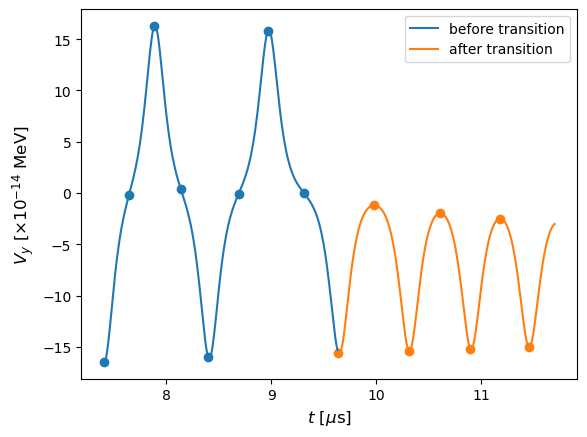

In [20]:
plt.figure()
plt.scatter(t[t_index][43:51], Vy[Vy_index][43:51]*1e14)
plt.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e14, label=r"before transition")
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$V_y~[\times 10^{-14}~\text{MeV}]$", fontsize=12)
plt.scatter(t[t_index][51:], Vy[Vy_index][51:]*1e14)
plt.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e14, label=r"after transition")
plt.legend()

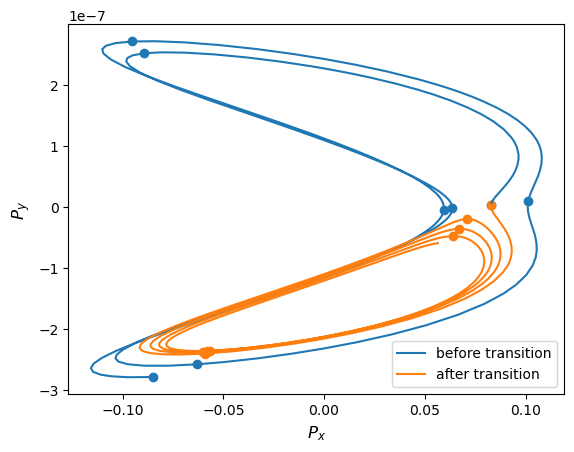

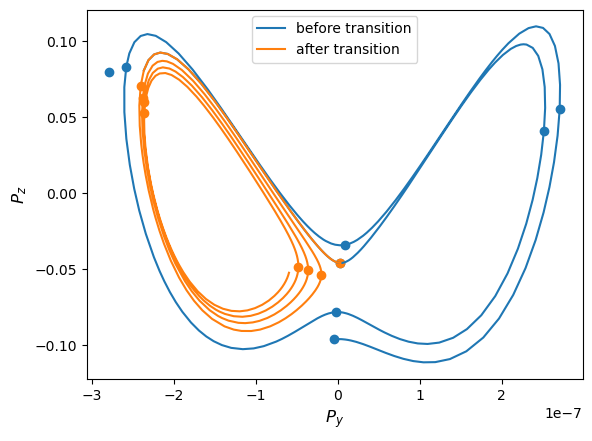

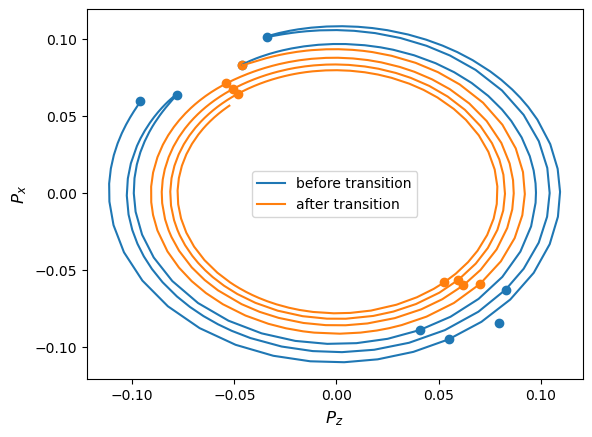

In [21]:
#just before and just after transition on same plot, QKE

plt.figure()
plt.scatter(Px[t_index,15][43:51], Py[t_index,15][43:51])
plt.plot(Px[t_index[43]:t_index[50],15], Py[t_index[43]:t_index[50],15],  label=r"before transition")
plt.scatter(Px[t_index,15][50:], Py[t_index,15][50:])
plt.plot(Px[t_index[50]:,15], Py[t_index[50]:,15],  label=r"after transition")
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
plt.legend()


plt.figure()
plt.scatter(Py[t_index,15][43:51], Pz[t_index,15][43:51])
plt.plot(Py[t_index[44]:t_index[51],15], Pz[t_index[44]:t_index[51],15], label=r"before transition")
plt.scatter(Py[t_index,15][50:], Pz[t_index,15][50:])
plt.plot(Py[t_index[50]:,15], Pz[t_index[50]:,15], label=r"after transition")
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
plt.legend()

plt.figure()
plt.scatter(Pz[t_index,15][43:51],Px[t_index,15][43:51])
plt.plot(Pz[t_index[44]:t_index[50],15], Px[t_index[44]:t_index[50],15], label=r"before transition")
plt.scatter(Pz[t_index,15][50:], Px[t_index,15][50:])
plt.plot(Pz[t_index[50]:,15], Px[t_index[50]:,15], label=r"after transition")
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
plt.legend()